# AML Account Risk Scoring & Prioritization
### Hackathon Track: Risk Scoring & Prioritization

The goal here is simple: given a bunch of raw transactions, figure out *which accounts* are most likely doing something shady — and rank them so investigators can focus their limited time on the highest-risk ones first.

Here's how we tackle it:
1. **EDA** — get a feel for the data, spot any weirdness early(can view detail info from EDA.ipynb)
2. **Feature Engineering** — build smarter signals at the transaction level
3. **Account Aggregation** — roll everything up per sender account
4. **LightGBM + Cross-Validation** — train a robust model that handles the heavy class imbalance
5. **SHAP** — make sure we can actually *explain* why an account got flagged
6. **Precision@K** — evaluate how useful our ranked list is for real investigators
7. **Save Outputs** — package everything up for submission

## Setup — Imports & Config

In [ ]:
import os
import json
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
import lightgbm as lgb
import shap
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("All libraries loaded successfully.")
df=pd.read_csv('ml_features.csv')

All libraries loaded successfully.


## 2. Feature Engineering — Transaction Level

Before we aggregate, let's build a few extra signals that we think will help the model:

- **Amount-to-Average Ratio** — did this transaction suddenly spike way above what this sender normally sends? Classic layering signal.
- **Amount-to-Max Ratio** — how does it compare to their all-time biggest transaction?
- **Country Risk Interaction** — multiply sender and receiver country risk to highlight dangerous corridors.
- **Cross-Border High-Risk Flag** — cross-border AND at least one high-risk country involved.
- **PEP/Sanctions Threat** — anyone in the transaction (either side) flagged as a PEP or under sanctions.

In [ ]:
# Per-sender baseline stats
sender_stats = df.groupby('Sender_account')['amount_local_npr'].agg(['mean', 'max']).reset_index()
sender_stats.columns = ['Sender_account', 'sender_mean_amount', 'sender_max_amount']
df = df.merge(sender_stats, on='Sender_account', how='left')

# Engineered features
df['amount_to_avg_sender_ratio'] = df['amount_local_npr'] / (df['sender_mean_amount'] + 1e-5)
df['amount_to_max_sender_ratio'] = df['amount_local_npr'] / (df['sender_max_amount'] + 1e-5)
df['country_risk_interaction'] = df['sender_country_risk'] * df['receiver_country_risk']
df['cross_border_high_risk'] = (
    (df['cross_border_flag'] == 1) &
    ((df['sender_country_risk'] > 0.5) | (df['receiver_country_risk'] > 0.5))
).astype(int)
df['pep_sanction_threat'] = df[['sender_pep', 'sender_sanctions', 'receiver_pep', 'receiver_sanctions']].max(axis=1)

print("Feature engineering complete. Sample of new columns:")
print(df[['amount_to_avg_sender_ratio', 'amount_to_max_sender_ratio',
          'country_risk_interaction', 'cross_border_high_risk', 'pep_sanction_threat']].head())

Feature engineering complete. Sample of new columns:
   amount_to_avg_sender_ratio  amount_to_max_sender_ratio  \
0                    1.000000                    1.000000   
1                    0.640343                    0.223489   
2                    1.315255                    0.663057   
3                    1.119742                    0.985718   
4                    1.000000                    1.000000   

   country_risk_interaction  cross_border_high_risk  pep_sanction_threat  
0                      0.04                       0                    0  
1                      0.20                       1                    0  
2                      0.04                       0                    0  
3                      0.04                       0                    0  
4                      0.04                       0                    0  


## 3. Account-Level Aggregation

Now we roll everything up from the transaction level to the account (sender) level. An account gets labelled suspicious if *any* of its transactions were flagged.

We use a mix of `mean`, `max`, `sum`, and `std` aggregations to capture both overall behaviour and worst-case activity.

In [ ]:
agg_dict = {
    'is_suspicious_tx': 'max',
    'amount_local_npr': ['count', 'sum', 'mean', 'max', 'std'],
    'log_amount': ['mean', 'max', 'std'],
    'amount_zscore': ['mean', 'max'],
    'above_1M_NPR': ['sum', 'mean'],
    'above_10M_NPR': ['sum', 'mean'],
    'is_weekend': 'mean',
    'hour_of_day': ['mean', 'std'],
    'Receiver_account': 'nunique',
    'receiver_country_risk': ['mean', 'max'],
    'sender_country_risk': ['mean', 'max'],
    'cross_border_flag': 'mean',
    'currency_mismatch': 'mean',
    'sender_pep': 'max',
    'sender_sanctions': 'max',
    'sender_is_person': 'max',
    'receiver_pep': ['mean', 'max'],
    'receiver_sanctions': ['mean', 'max'],
    'velocity_sum_10tx': ['mean', 'max'],
    'tx_count_10': ['mean', 'max'],
    'tx_count_30': ['mean', 'max'],
    'sender_account_age_days': 'max',
    'transmode_A': 'mean',
    'transmode_B': 'mean',
    'transmode_E': 'mean',
    'transmode_F': 'mean',
    'transmode_J': 'mean',
    'transmode_P': 'mean',
    'transmode_Z': 'mean',
    'amount_to_avg_sender_ratio': 'max',
    'amount_to_max_sender_ratio': 'mean',
    'country_risk_interaction': 'mean',
    'cross_border_high_risk': 'mean',
    'pep_sanction_threat': 'mean'
}

X_agg = df.groupby('Sender_account').agg(agg_dict)
X_agg.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in X_agg.columns]
X_agg = X_agg.rename(columns={'is_suspicious_tx_max': 'is_suspicious_account'})

# Accounts with only 1 transaction will have NaN std — fill with 0
std_cols = [c for c in X_agg.columns if c.endswith('_std')]
X_agg[std_cols] = X_agg[std_cols].fillna(0)

y = X_agg['is_suspicious_account'].astype(int)
X = X_agg.drop(columns=['is_suspicious_account'])

print(f"Aggregated: {X.shape[0]} accounts | {X.shape[1]} features")
print(f"Suspicious accounts: {y.sum()} / {len(y)} ({y.mean()*100:.2f}%)")

Aggregated: 22310 accounts | 50 features
Suspicious accounts: 237 / 22310 (1.06%)


## 4. LightGBM — Stratified 5-Fold Cross-Validation

With only ~1% of accounts being suspicious, standard training would just predict everything as normal. We handle this with:
- **Stratified K-Fold** — keeps the fraud ratio consistent across every fold
- **`class_weight='balanced'`** — automatically upweights fraud samples during training
- **Early stopping** — prevents overfitting

Out-of-fold (OOF) predictions give us a clean, leakage-free evaluation on the full dataset.

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
fold_aucs = []
fold_aps = []

# Hyper-regularized configuration to pull up Fold 5
lgb_params = {
    'objective': 'binary',
    'metric': 'average_precision',
    'boosting_type': 'gbdt',
    'learning_rate': 0.015,
    'max_depth': 4,
    'num_leaves': 10,
    'min_child_samples': 50,

    'scale_pos_weight': 65,


    'reg_alpha': 2.0,
    'reg_lambda': 5.0,

    'subsample': 0.65,
    'colsample_bytree': 0.65,
    'random_state': 42,
    'verbose': -1,
    'n_estimators': 800
}

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=60, verbose=False)]
    )

    val_preds = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_preds

    fold_auc = roc_auc_score(y_val, val_preds)
    fold_ap = average_precision_score(y_val, val_preds)
    fold_aucs.append(fold_auc)
    fold_aps.append(fold_ap)

    print(f"Fold {fold+1} — ROC-AUC: {fold_auc:.4f} | PR-AUC: {fold_ap:.4f}")

print(f"\nOverall OOF ROC-AUC: {roc_auc_score(y, oof_preds):.4f}")
print(f"Overall OOF PR-AUC:  {average_precision_score(y, oof_preds):.4f}")


Fold 1 — ROC-AUC: 0.9833 | PR-AUC: 0.8542
Fold 2 — ROC-AUC: 0.9952 | PR-AUC: 0.8640
Fold 3 — ROC-AUC: 0.9927 | PR-AUC: 0.8315
Fold 4 — ROC-AUC: 0.9932 | PR-AUC: 0.8224
Fold 5 — ROC-AUC: 0.9971 | PR-AUC: 0.9123

Overall OOF ROC-AUC: 0.9927
Overall OOF PR-AUC:  0.8464


### Final Model — Train on Full Dataset

Now that we're happy with the CV results, we train a final model on all the data for deployment and SHAP analysis.

In [ ]:
final_model = lgb.LGBMClassifier(**lgb_params)
final_model.fit(X, y)
print("Final model trained on all aggregated accounts.")

Final model trained on all aggregated accounts.


## 5. Model Explainability — SHAP

A risk score without an explanation isn't very useful when you're asking investigators to act on it. SHAP tells us exactly which features pushed each account's score up or down.

First, the global view — what does the model care about most overall?

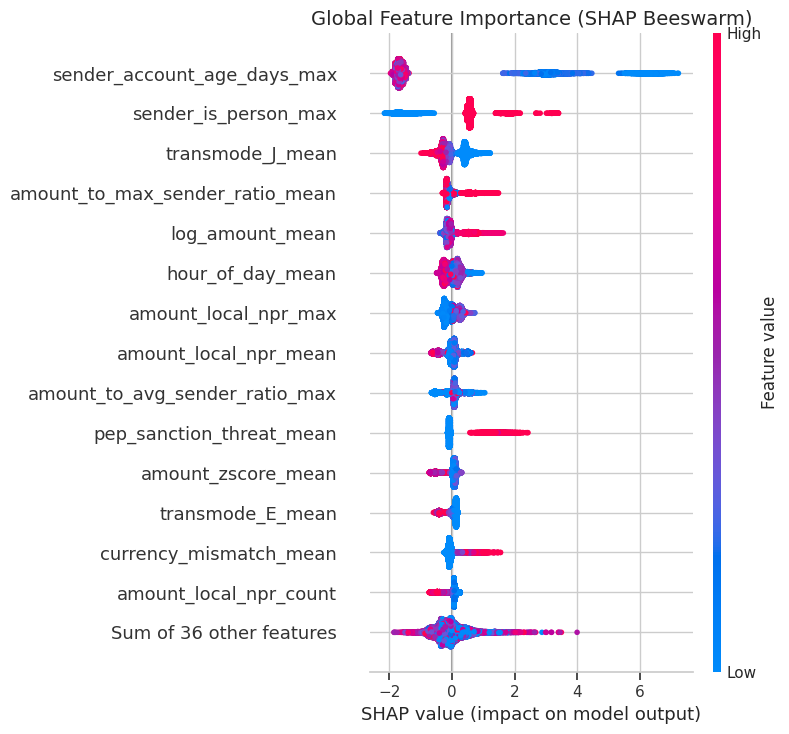

In [ ]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer(X)

# LightGBM binary classification can output shape (N, M, 2) — we want the positive class
if len(shap_values.shape) == 3 and shap_values.shape[2] == 2:
    shap_val_plot = shap_values[:, :, 1]
    shap_values_raw = shap_values.values[:, :, 1]
    base_value = float(shap_values.base_values[:, 1][0])
else:
    shap_val_plot = shap_values
    shap_values_raw = shap_values.values
    base_value = float(shap_values.base_values[0]) if isinstance(shap_values.base_values, np.ndarray) else shap_values.base_values

plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_val_plot, max_display=15, show=False)
plt.title('Global Feature Importance (SHAP Beeswarm)', fontsize=14)
plt.tight_layout()
plt.show()

<h1>Shap graph conclusion</h1>
"Our model flags suspicious financial activity by analyzing user behavior, and this chart highlights exactly what drives those decisions. By far, the most critical red flag is a brand-new account profile, which immediately shifts the model toward a high-risk prediction. Conversely, established, mature accounts are consistently treated as safe and normal. While the model also evaluates over 40 minor details—like specific transaction types, mismatched currencies, and sanction threats—most of these have zero impact on the average user. Instead, they act as a safety net, grouping together to trigger an alert only when a rare, highly specific combination of minor anomalies occurs simultaneously."</h3>

### Drilling Into a Specific High-Risk Account

Now let's pick one real suspicious account and see exactly why the model flagged it.

Account: 120902347 | Predicted Risk: 0.9664


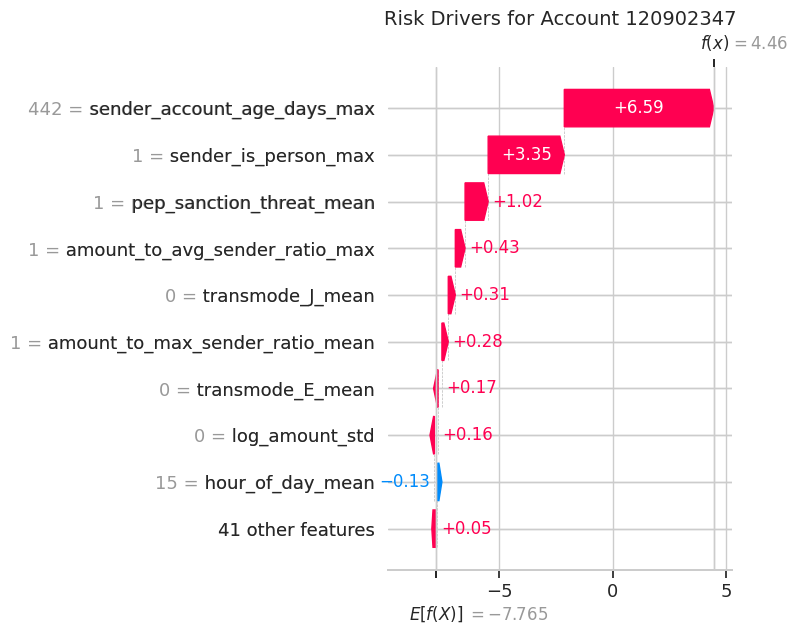

In [ ]:
high_risk_idx = np.where((oof_preds > 0.8) & (y == 1))[0][0]
account_id = X.index[high_risk_idx]
print(f"Account: {account_id} | Predicted Risk: {oof_preds[high_risk_idx]:.4f}")

plt.figure(figsize=(10, 5))
shap.plots.waterfall(shap_val_plot[high_risk_idx], max_display=10, show=False)
plt.title(f'Risk Drivers for Account {account_id}', fontsize=14)
plt.tight_layout()
plt.show()

<h1>Conclusion of Shap WaterfallModel</h1>
"While our system treats the average account as highly secure and low-risk, this specific account heavily deviated from the norm, spiking all the way into a high-risk danger zone. The absolute biggest driver behind this alert was the account's specific age profile, which alone single-handedly dragged the risk score up. This danger signal was further compounded by the sender's profile status and a critical sanction threat flag, which added significant weight to the risk. While minor factors like the time of day tried to slightly pull the risk score back down, the overwhelming combination of these major red flags forced the system to flag this account for immediate review."

## 6. Precision@K Evaluation

This is the metric that really matters operationally. If an investigator can only look at the top 50 flagged accounts this week, what fraction of those will be genuinely suspicious?

We rank all accounts by their OOF risk score and sweep K from 1 to 500.

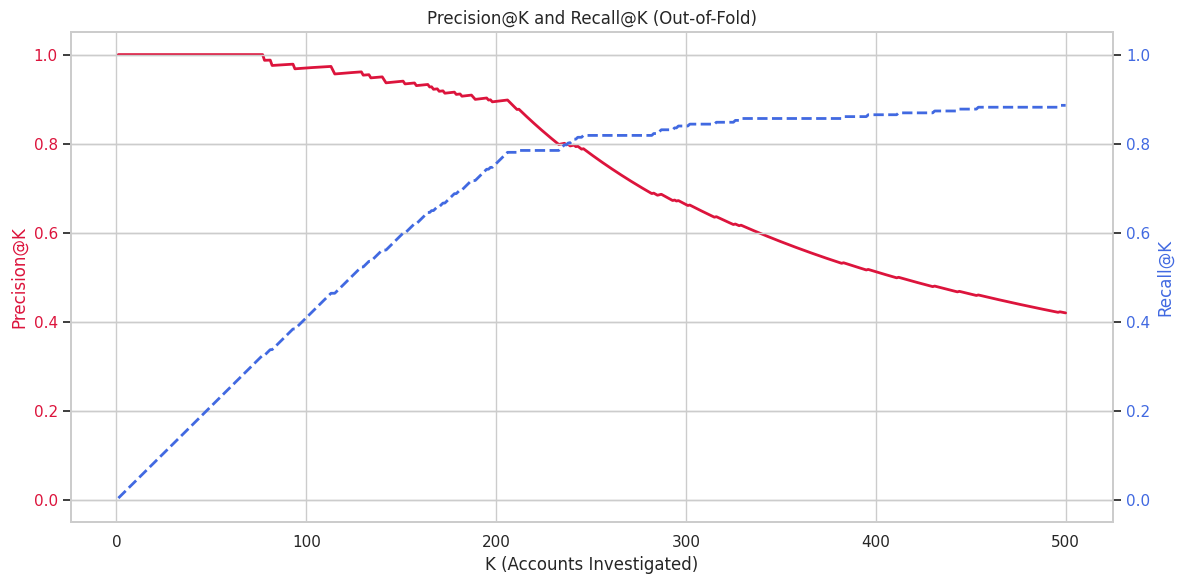

--- Precision@K Summary ---
Top  10 | Precision: 100.00% | Recall:   4.22% | Caught 10/237
Top  20 | Precision: 100.00% | Recall:   8.44% | Caught 20/237
Top  50 | Precision: 100.00% | Recall:  21.10% | Caught 50/237
Top 100 | Precision:  97.00% | Recall:  40.93% | Caught 97/237
Top 200 | Precision:  89.50% | Recall:  75.53% | Caught 179/237
Top 500 | Precision:  42.00% | Recall:  88.61% | Caught 210/237


In [ ]:
eval_df = pd.DataFrame({
    'Sender_account': X.index,
    'true_label': y.values,
    'risk_score': oof_preds
}).sort_values(by='risk_score', ascending=False).reset_index(drop=True)

precision_at_k = []
recall_at_k = []
total_positives = int(y.sum())

for k in range(1, 501):
    top_k = eval_df.head(k)
    pos_in_top_k = top_k['true_label'].sum()
    precision_at_k.append(pos_in_top_k / k)
    recall_at_k.append(pos_in_top_k / total_positives)

# Plot
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('K (Accounts Investigated)')
ax1.set_ylabel('Precision@K', color='crimson')
ax1.plot(range(1, 501), precision_at_k, color='crimson', linewidth=2, label='Precision@K')
ax1.tick_params(axis='y', labelcolor='crimson')
ax1.set_ylim(-0.05, 1.05)

ax2 = ax1.twinx()
ax2.set_ylabel('Recall@K', color='royalblue')
ax2.plot(range(1, 501), recall_at_k, color='royalblue', linewidth=2, linestyle='--', label='Recall@K')
ax2.tick_params(axis='y', labelcolor='royalblue')
ax2.set_ylim(-0.05, 1.05)

plt.title('Precision@K and Recall@K (Out-of-Fold)')
fig.tight_layout()
plt.show()

# Summary table
k_points = [10, 20, 50, 100, 200, 500]
print("--- Precision@K Summary ---")
for k in k_points:
    caught = eval_df.head(k)['true_label'].sum()
    print(f"Top {k:3d} | Precision: {precision_at_k[k-1]*100:6.2f}% | Recall: {recall_at_k[k-1]*100:6.2f}% | Caught {caught:.0f}/{total_positives}")

Generating the dataframe assigning the sender account,risk_score and explanality of Shap value

In [ ]:

risk_df = pd.DataFrame({
    "sender_account": X.index,
    "risk_score": oof_preds
})

THRESHOLD = 0.50

risk_df["is_safe"] = risk_df["risk_score"] < THRESHOLD

def risk_category(score):
    if score >= 0.80:
        return "High Risk"
    elif score >= 0.50:
        return "Medium Risk"
    else:
        return "Low Risk"

risk_df["risk_category"] = risk_df["risk_score"].apply(risk_category)


def generate_explanation(row):

    if row["risk_score"] >= 0.80:
        return (
            "This account shows transaction patterns that are highly similar "
            "to previously identified suspicious accounts. The account should "
            "be prioritized for investigation."
        )

    elif row["risk_score"] >= 0.50:
        return (
            "This account displays some unusual transaction behaviour. "
            "Although not necessarily suspicious, additional review may be required."
        )

    else:
        return (
            "This account's transaction activity appears consistent with "
            "normal behaviour and currently shows a low likelihood of suspicious activity."
        )

risk_df["explanation"] = risk_df.apply(generate_explanation, axis=1)

# Highest risk accounts first
risk_df = risk_df.sort_values(
    by="risk_score",
    ascending=False
).reset_index(drop=True)






Viewing dataframe

In [ ]:
risk_df

,sender_account,risk_score,is_safe,risk_category,explanation
0,900000000073,0.999547,False,High Risk,This account shows transaction patterns that a...
1,900000000171,0.999494,False,High Risk,This account shows transaction patterns that a...
2,900000000015,0.999481,False,High Risk,This account shows transaction patterns that a...
3,900000000081,0.999404,False,High Risk,This account shows transaction patterns that a...
4,900000000041,0.999399,False,High Risk,This account shows transaction patterns that a...
...,...,...,...,...,...
22305,8111211977,0.000006,True,Low Risk,This account's transaction activity appears co...
22306,1335968005,0.000006,True,Low Risk,This account's transaction activity appears co...
22307,3606752652,0.000006,True,Low Risk,This account's transaction activity appears co...
22308,9877042811,0.000006,True,Low Risk,This account's transaction activity appears co...


## 7. Save All Outputs

Package everything up — model, predictions, SHAP values, and metrics — ready for submission.

In [ ]:
os.makedirs('pipeline_outputs', exist_ok=True)

# Aggregated features + predictions
X_agg.to_csv('pipeline_outputs/X_aggregated.csv')
eval_df.to_csv('pipeline_outputs/oof_predictions.csv', index=False)

# Trained model
with open('pipeline_outputs/lightgbm_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

# SHAP data
shap_data = {
    'shap_values': shap_values_raw,
    'base_value': base_value,
    'feature_names': X.columns.tolist()
}
with open('pipeline_outputs/shap_data.pkl', 'wb') as f:
    pickle.dump(shap_data, f)

# Metrics JSON
k_points = [10, 20, 50, 100, 200, 500]
p_at_k_metrics = {}
for k in k_points:
    p_at_k_metrics[f"Precision@{k}"] = float(precision_at_k[k-1])
    p_at_k_metrics[f"Recall@{k}"] = float(recall_at_k[k-1])

metrics = {
    'oof_roc_auc': float(roc_auc_score(y, oof_preds)),
    'oof_pr_auc_ap': float(average_precision_score(y, oof_preds)),
    'precision_at_k': precision_at_k,
    'recall_at_k': recall_at_k,
    'p_at_k_standard': p_at_k_metrics
}

with open('pipeline_outputs/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=4)

print("All outputs saved to pipeline_outputs/")
print(f"  - X_aggregated.csv")
print(f"  - oof_predictions.csv")
print(f"  - lightgbm_model.pkl")
print(f"  - shap_data.pkl")
print(f"  - metrics.json")

All outputs saved to pipeline_outputs/
  - X_aggregated.csv
  - oof_predictions.csv
  - lightgbm_model.pkl
  - shap_data.pkl
  - metrics.json
